# Product Recommendation System

## 1. Data Loading & Preprocessing


### 1.1 Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx




### 1.2 Load dataset

In [ ]:
df=pd.read_csv('walmart.tsv',sep='\t')

### 1.3 Handle missing values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Uniq Id                          5000 non-null   object 
 1   Crawl Timestamp                  5000 non-null   object 
 2   Dataset Origin                   0 non-null      float64
 3   Product Id                       5000 non-null   object 
 4   Product Barcode                  0 non-null      float64
 5   Product Company Type Source      5000 non-null   object 
 6   Product Brand Source             139 non-null    object 
 7   Product Brand Normalised Source  139 non-null    object 
 8   Product Name Source              139 non-null    object 
 9   Match Rank                       0 non-null      float64
 10  Match Score                      0 non-null      float64
 11  Match Type                       0 non-null      float64
 12  Retailer            

In [ ]:
df.head()

,Uniq Id,Crawl Timestamp,Dataset Origin,Product Id,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,Product Image Url,Product Model Number,Product Tags,Product Contents,Product Rating,Product Reviews Count,Bsr,Joining Key
0,1705736792d82aa2f2d3caf1c07c53f4,2020-09-24 03:21:12 +0000,NaN,2e17bf4acecdece67fc00f07ad62c910,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,NaN,NaN,NaN,81350af1be98d3753cf964709f0c766a
1,95a9fe6f4810fcfc7ff244fd06784f11,2020-10-30 14:04:08 +0000,NaN,076e5854a62dd283c253d6bae415af1f,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,NaN,"Nice 'n Easy Permanent Color, 111 Natural Medi...",NaN,NaN,NaN,NaN,0353e63907dc0de0c734db4690300057
2,8d4d0330178d3ed181b15a4102b287f2,2020-08-06 05:51:47 +0000,NaN,8a4fe5d9c7a6ed26cc44d785a454b124,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,NaN,Clairol Nice 'N Easy Permanent Color 7/106A Na...,NaN,4.5,29221.0,NaN,b6985c8e94815fbca2319dbb8bf228af
3,fddc4df45b35efd886794b261f730c51,2020-07-15 11:22:04 +0000,NaN,03b5fb878a33eadff8b033419eab9669,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/25b4b467-bc61...,NaN,"Kokie Professional Matte Lipstick, Hot Berry, ...",NaN,NaN,NaN,NaN,85b70fded09186f00467cea2f935b779
4,0990cf89a59ca6a0460349a3e4f51d42,2020-11-26T12:27:20+00:00,NaN,ce3d761e57d6ccad80619297b5b1bcbc,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,NaN,"Gillette TRAC II Plus Razor Blade Refills, Fit...",NaN,NaN,131.0,NaN,41c870871328e97da6fb036bb7d4b2da


In [ ]:
df = df[['Uniq Id','Product Id', 'Product Rating', 'Product Reviews Count', 'Product Category', 'Product Brand', 'Product Name', 'Product Image Url', 'Product Description', 'Product Tags']]


In [ ]:
df.shape

(5000, 10)

In [ ]:
df.isnull().sum()

,0
Uniq Id,0
Product Id,0
Product Rating,2806
Product Reviews Count,1654
Product Category,10
Product Brand,13
Product Name,0
Product Image Url,0
Product Description,1127
Product Tags,0


In [ ]:
df = df.dropna(subset=["Uniq Id", "Product Id", "Product Name"])
df["Product Brand"] = df["Product Brand"].fillna("")
df["Product Category"] = df["Product Category"].fillna("")
df["Product Description"] = df["Product Description"].fillna("")
df["Product Tags"] = df["Product Tags"].fillna("")
df["Product Rating"] = pd.to_numeric(df["Product Rating"], errors="coerce").clip(0,5)
df["Product Rating"] = df["Product Rating"].fillna(df["Product Rating"].median())
df["Product Reviews Count"] = pd.to_numeric(df["Product Reviews Count"], errors="coerce").fillna(0).astype(int)


In [ ]:
print("Missing values after cleaning:")
print(df.isna().sum())
df.info()
df.head(5)


Missing values after cleaning:
Uniq Id                  0
Product Id               0
Product Rating           0
Product Reviews Count    0
Product Category         0
Product Brand            0
Product Name             0
Product Image Url        0
Product Description      0
Product Tags             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Uniq Id                5000 non-null   object 
 1   Product Id             5000 non-null   object 
 2   Product Rating         5000 non-null   float64
 3   Product Reviews Count  5000 non-null   int64  
 4   Product Category       5000 non-null   object 
 5   Product Brand          5000 non-null   object 
 6   Product Name           5000 non-null   object 
 7   Product Image Url      5000 non-null   object 
 8   Product Description    5000 non-null   object 
 9   Pr

,Uniq Id,Product Id,Product Rating,Product Reviews Count,Product Category,Product Brand,Product Name,Product Image Url,Product Description,Product Tags
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,4.5,0,Premium Beauty > Premium Makeup > Premium Nail...,OPI,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,4.5,0,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,"Nice n Easy Permanent Color, 111 Natural Mediu...",https://i5.walmartimages.com/asr/9c8e42e4-13a5...,Pack of 3 Pack of 3 for the UPC: 381519000201 ...,"Nice 'n Easy Permanent Color, 111 Natural Medi..."
2,8d4d0330178d3ed181b15a4102b287f2,8a4fe5d9c7a6ed26cc44d785a454b124,4.5,29221,Beauty > Hair Care > Hair Color > Permanent Ha...,Clairol,Clairol Nice N Easy Permanent Color 7/106A Nat...,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,This Clairol Nice N Easy Permanent Color gives...,Clairol Nice 'N Easy Permanent Color 7/106A Na...
3,fddc4df45b35efd886794b261f730c51,03b5fb878a33eadff8b033419eab9669,4.5,0,Beauty > Makeup > Lip,Kokie Cosmetics,"Kokie Professional Matte Lipstick, Hot Berry, ...",https://i5.walmartimages.com/asr/25b4b467-bc61...,Calling all matte lip lovers! Indulge in our r...,"Kokie Professional Matte Lipstick, Hot Berry, ..."
4,0990cf89a59ca6a0460349a3e4f51d42,ce3d761e57d6ccad80619297b5b1bcbc,4.5,131,Seasonal > Stock Up Essentials > Personal Care...,Gillette,"Gillette TRAC II Plus Razor Blade Refills, Fit...",https://i5.walmartimages.com/asr/1a2ebb06-cd01...,"In 1971, Gillette introduced the Trac II razor...","Gillette TRAC II Plus Razor Blade Refills, Fit..."


### 1.4 Clean text fields

In [ ]:
df = df.drop_duplicates(subset=["Product Id"])
df = df.drop_duplicates(subset=["Product Name","Product Brand"])
df.reset_index(drop=True, inplace=True)


In [ ]:
import re

def clean_text(s):
    if pd.isna(s): return ""
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-z0-9\s\-\+]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

for col in ["Product Name","Product Brand","Product Category","Product Description","Product Tags"]:
    df[col] = df[col].astype(str).apply(clean_text)


In [ ]:
nlp = spacy.load("en_core_web_sm")
def clean_and_extract_tags(text):
    doc = nlp(str(text).lower())
    tags = [token.text for token in doc
            if token.is_alpha and token.text not in STOP_WORDS]
    return " ".join(tags)

columns_to_extract = ["Product Category", "Product Brand", "Product Description"]
for col in columns_to_extract:
    df[col] = df[col].fillna("").apply(clean_and_extract_tags)

df["Product Tags"] = df[columns_to_extract].apply(lambda row: " ".join(row), axis=1)


In [ ]:
df_rb = df[[
    "Product Id","Product Name","Product Brand","Product Category",
    "Product Rating","Product Reviews Count","Product Image Url"
]].copy()

df_rb["Product Rating"] = pd.to_numeric(df_rb["Product Rating"], errors="coerce").clip(0,5).fillna(0.0)
df_rb["Product Reviews Count"] = pd.to_numeric(df_rb["Product Reviews Count"], errors="coerce").fillna(0).clip(lower=0).astype(int)


In [ ]:
df["text_features"] = (
    df["Product Name"].fillna("") + " " +
    df["Product Brand"].fillna("") + " " +
    df["Product Category"].fillna("") + " " +
    df["Product Tags"].fillna("") + " " +
    df["Product Description"].fillna("")
).str.strip()


## 2. Exploratory Data Analysis

### 2.1 Distribution of Product Ratings

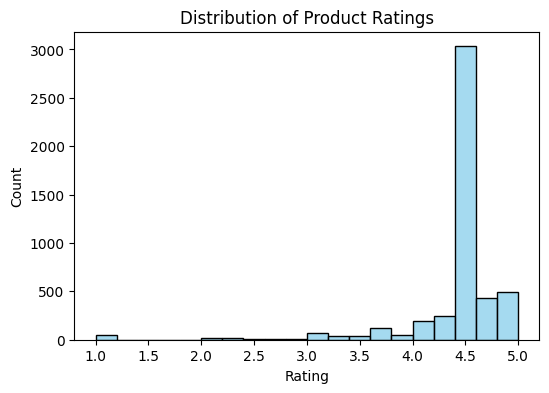

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Product Rating"], bins=20, kde=False, color="skyblue")
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### 2.2 Distribution of Reviews Count

> Add blockquote



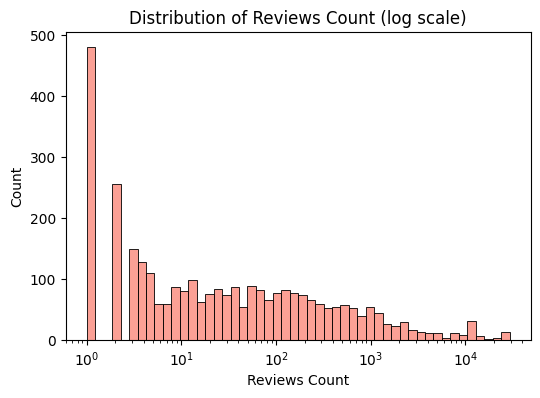

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Product Reviews Count"], bins=50, color="salmon", log_scale=(True, False))
plt.title("Distribution of Reviews Count (log scale)")
plt.xlabel("Reviews Count")
plt.ylabel("Count")
plt.show()

### 2.3 Top 15 Product Categories




/tmp/ipython-input-1541995158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis")


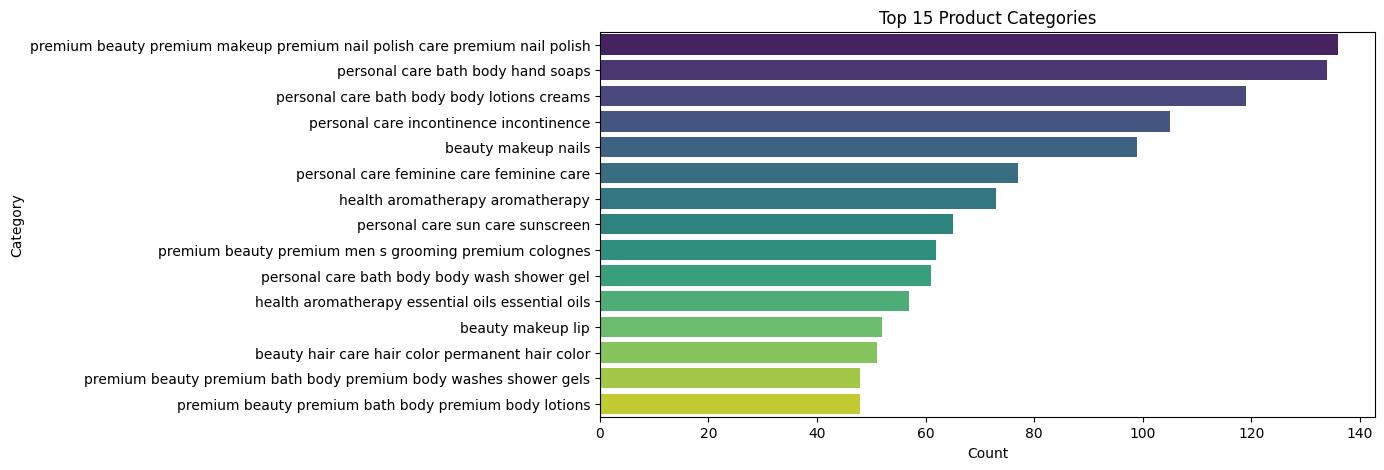

In [ ]:
plt.figure(figsize=(10,5))
top_cats = df["Product Category"].value_counts().head(15)
sns.barplot(x=top_cats.values, y=top_cats.index, palette="viridis")
plt.title("Top 15 Product Categories")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

###2.4 Top 15 Brands

/tmp/ipython-input-912682363.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="magma")


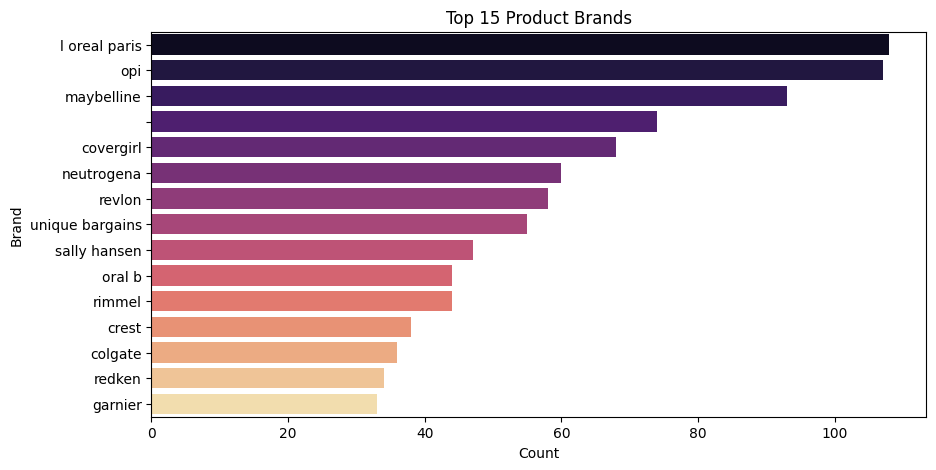

In [ ]:
plt.figure(figsize=(10,5))
top_brands = df["Product Brand"].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, palette="magma")
plt.title("Top 15 Product Brands")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

 ### 2.5 Ratings vs. Reviews

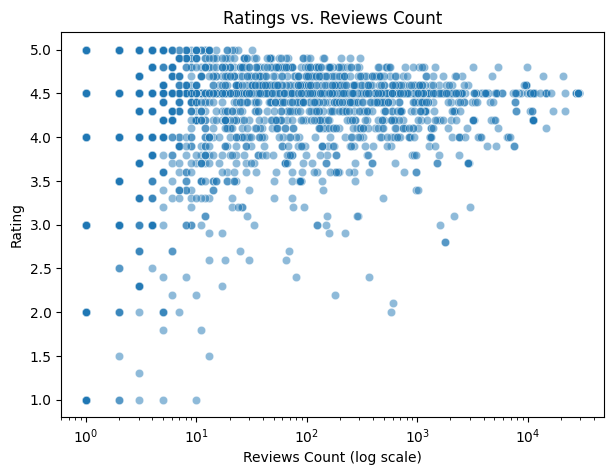

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Product Reviews Count", y="Product Rating", alpha=0.5)
plt.xscale("log")
plt.title("Ratings vs. Reviews Count")
plt.xlabel("Reviews Count (log scale)")
plt.ylabel("Rating")
plt.show()

## Models

### 3.1 Popularity-Based Recommender
- Formula: weighted rating + demand
- Returns trending/highly rated products

In [ ]:
R = df_rb["Product Rating"]
v = df_rb["Product Reviews Count"]
C = R.mean()
m = np.percentile(v, 60)

weighted = (v/(v+m))*R + (m/(v+m))*C
demand = np.log1p(v)
score_raw = 0.85*weighted + 0.15*demand
df_rb["popularity_score"] = MinMaxScaler().fit_transform(score_raw.to_numpy().reshape(-1,1)).ravel()


In [ ]:
def top_overall(k=10, min_reviews=0):
    s = df_rb[df_rb["Product Reviews Count"] >= int(min_reviews)]
    return (s.sort_values("popularity_score", ascending=False)
              .head(k)[["Product Id","Product Name","Product Brand","Product Category",
                        "Product Rating","Product Reviews Count","popularity_score","Product Image Url"]]
              .reset_index(drop=True))

def top_in_category(category, k=10, min_reviews=0):
    s = df_rb[(df_rb["Product Category"]==str(category)) &
              (df_rb["Product Reviews Count"] >= int(min_reviews))]
    return (s.sort_values("popularity_score", ascending=False)
              .head(k)[["Product Id","Product Name","Product Brand","Product Rating",
                        "Product Reviews Count","popularity_score","Product Image Url"]]
              .reset_index(drop=True))

def top_for_brand(brand, k=10, min_reviews=0):
    s = df_rb[(df_rb["Product Brand"]==str(brand)) &
              (df_rb["Product Reviews Count"] >= int(min_reviews))]
    return (s.sort_values("popularity_score", ascending=False)
              .head(k)[["Product Id","Product Name","Product Category","Product Rating",
                        "Product Reviews Count","popularity_score","Product Image Url"]]
              .reset_index(drop=True))


In [ ]:
# Top 10 overall products (with at least 3 reviews)
print("🔹 Top 10 Overall Products (min_reviews=3)")
display(top_overall(k=10, min_reviews=3))

# Top 10 products in the most common category
example_cat = df_rb["Product Category"].mode().iloc[0]
print(f"\n🔹 Top 10 Products in Category: {example_cat} (min_reviews=3)")
display(top_in_category(example_cat, k=10, min_reviews=3))

# Top 10 products for the most common brand
example_brand = df_rb["Product Brand"].mode().iloc[0]
print(f"\n🔹 Top 10 Products for Brand: {example_brand} (min_reviews=3)")
display(top_for_brand(example_brand, k=10, min_reviews=3))


🔹 Top 10 Overall Products (min_reviews=3)


,Product Id,Product Name,Product Brand,Product Category,Product Rating,Product Reviews Count,popularity_score,Product Image Url
0,a8fe0ccaa367c5d593f90eee570b1287,pine-sol multi-surface cleaner original 144 oz...,clorox,household essentials cleaning supplies purpose...,4.7,20997,1.000000,https://i5.walmartimages.com/asr/3e98414e-3779...
1,b43880d4d715bef700d0225555794ca0,pine-sol all-purpose cleaner lemon 144 oz bottle,pine sol,household essentials cleaning supplies purpose...,4.8,9806,0.990176,https://i5.walmartimages.com/asr/cf14ba1d-834d...
2,970b3273971e53075dc34181cb95ad9e,garnier whole blends repairing shampoo honey t...,garnier,beauty hair care hair care brands garnier hair...,4.7,13809,0.978964,https://i5.walmartimages.com/asr/e30b8e1a-5538...
3,a456ba45a3c77a2f04f5901dd5b88484,cascade platinum actionpacs dishwasher deterge...,cascade,household essentials cleaning supplies dishwas...,4.8,5388,0.960068,https://i5.walmartimages.com/asr/e42f8558-9bff...
4,d9978813405b8576df47d69dd1832f19,clairol nice n easy sun-kissed permanent hair ...,clairol,beauty hair care hair color permanent hair color,4.5,29242,0.959789,https://i5.walmartimages.com/asr/8adedd89-c601...
5,8a4fe5d9c7a6ed26cc44d785a454b124,clairol nice n easy permanent color 7 106a nat...,clairol,beauty hair care hair color permanent hair color,4.5,29221,0.959753,https://i5.walmartimages.com/asr/e3a601c2-6a2b...
6,d53bb340f54fb704c7903e9444ce6e1a,clairol nice n easy permanent hair color 4 120...,clairol,beauty hair care hair color permanent hair color,4.5,29221,0.959753,https://i5.walmartimages.com/asr/924961cf-23ac...
7,252a08a5840e6c870f194212973248c5,clairol nice n easy permanent color 6g 116a na...,clairol,beauty hair care hair color permanent hair color,4.5,29221,0.959753,https://i5.walmartimages.com/asr/8ede5176-2b60...
8,9f53397c7ca776103acf8802afa0d312,clairol nice n easy permanent hair color natur...,clairol,beauty hair care hair color permanent hair color,4.5,29216,0.959744,https://i5.walmartimages.com/asr/815395cc-87a5...
9,5a2d616aad50981462fd768928a3763d,clairol nicen easy permanent hair color cr me ...,clairol,beauty hair care hair color permanent hair color,4.5,28678,0.958812,https://i5.walmartimages.com/asr/5487d53c-555b...



🔹 Top 10 Products in Category: premium beauty premium makeup premium nail polish care premium nail polish (min_reviews=3)


,Product Id,Product Name,Product Brand,Product Rating,Product Reviews Count,popularity_score,Product Image Url
0,7b79fc97794dcc25409bd5b990e77053,cnd vinylux weekly nail polish black pool 0 5 ...,cnd,4.5,763,0.776696,https://i5.walmartimages.com/asr/976df8f6-bb67...
1,460aacbafc0771fe2db33f6851a57d12,opi nail polish tiramisu for two 0 5 fl oz,opi,4.5,366,0.739632,https://i5.walmartimages.com/asr/7d565996-3e6a...
2,8e5ab206db0cc7d47b07dcc73d20c8b4,50 off julep zodiac collection nail polish glo...,julep,4.5,117,0.681608,https://i5.walmartimages.com/asr/fe817d82-2934...
3,2520ceb306c92b9ad6f67b222105b3ca,opi nail polish machu peach-u 0 5 fl oz,opi,4.3,331,0.679039,https://i5.walmartimages.com/asr/2d8f8250-86c2...
4,1c39b6e36ec95f940a8bc6821e25c0f9,opi nail polish closer than you might bel m 0 ...,opi,5.0,11,0.639960,https://i5.walmartimages.com/asr/d6e17601-0b25...
5,1a68b5274d4730747ca537d71f49a475,opi nail polish hotter than you pink 0 5 fl oz,opi,4.4,61,0.622848,https://i5.walmartimages.com/asr/8feef376-77ea...
6,f58dc0ec4f9a4da54e764e1b787acf2e,opi nail polish strawberry margarita 0 5 fl oz,opi,4.4,57,0.619521,https://i5.walmartimages.com/asr/b95676e5-96ab...
7,ea545ee527161c8326d76c605bb0a46b,opi nail polish nothin mousie 0 5 fl oz,opi,4.4,57,0.619521,https://i5.walmartimages.com/asr/3c343190-a680...
8,0ed00b2d38e221c7fe7549e3d44f483c,nicole by opi nail lacquer,opi,4.8,13,0.619241,https://i5.walmartimages.com/asr/af6a36f2-21a2...
9,8014be2e6a4da61c326b0e5bb278dbff,opi gelcolor gel nail polish lisbon wants moor...,opi,4.5,15,0.574010,https://i5.walmartimages.com/asr/ed0cf7fa-440a...



🔹 Top 10 Products for Brand: l oreal paris (min_reviews=3)


,Product Id,Product Name,Product Category,Product Rating,Product Reviews Count,popularity_score,Product Image Url
0,b039fc42321106b9f5a60e50613ea990,loreal paris magic root cover up gray conceale...,beauty premium beauty premium hair care,4.5,7299,0.890155,https://i5.walmartimages.com/asr/e3b531fa-ecd1...
1,957ba5ee2c39775f3113932d8ebe7fd2,loreal paris feria multi-faceted shimmering pe...,beauty hair care hair color red hair dye,4.5,2225,0.830515,https://i5.walmartimages.com/asr/18677b94-53a4...
2,8a723fae706cd0135037a1091c5a993a,loreal paris superior preference fade-defying ...,beauty hair care hair color permanent hair color,4.5,1916,0.823004,https://i5.walmartimages.com/asr/d026502f-46fc...
3,1f7c99f8ed4952cc6405cd632aa0a69d,loreal paris lash paradise mascara voluminous ...,beauty makeup eye makeup mascara l oreal mascara,4.5,1883,0.822131,https://i5.walmartimages.com/asr/2935b82c-e6d7...
4,2fccae8c299f3c29fe93017ea779a1f4,loreal paris colorista semi-permanent hair col...,beauty hair care hair color hair bleach,4.5,1860,0.821513,https://i5.walmartimages.com/asr/a0992a6b-09d3...
5,73f198100fab300cc3987869b7ed0492,loreal paris colorista semi-permanent hair col...,beauty hair care hair color hair bleach,4.5,1860,0.821513,https://i5.walmartimages.com/asr/2b400573-6e53...
6,ecc6a40ea9f300daaa48cccc691045c7,loreal paris infallible paints eye shadow shad...,beauty travel size beauty travel size makeup t...,4.5,1721,0.817611,https://i5.walmartimages.com/asr/bb9aadef-863a...
7,5bbb9291dee8c357fa5e54d11e42e18f,loreal paris pure sugar scrub with grapeseed t...,beauty skin care facial cleansers exfoliators ...,4.5,1138,0.796816,https://i5.walmartimages.com/asr/8412c826-ac49...
8,e3c043c2ebd1791dccc5c3aa20314825,loreal paris telescopic original washable inte...,beauty travel size beauty travel size makeup t...,4.5,1113,0.795699,https://i5.walmartimages.com/asr/2e4409c2-fd27...
9,2ab8b8b553b3d97ea00afa8748c487c5,loreal paris elvive extraordinary clay rebalan...,beauty hair care shampoo l oreal shampoo,4.4,1891,0.794039,https://i5.walmartimages.com/asr/dd6fa9f0-4180...


### 3.2 Content-Based Recommender (TF-IDF + Cosine)
- Uses product name, brand, category, description, tags
- Finds semantically similar items


In [ ]:
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2, max_features=30000)
X = tfidf.fit_transform(df["text_features"])


In [ ]:
nn = NearestNeighbors(n_neighbors=51, metric="cosine", algorithm="brute")
nn.fit(X)

idx_by_pid = {pid: i for i, pid in enumerate(df["Product Id"])}


In [ ]:
def recommend_by_id(product_id, k=10, same_category=True, exclude_same_brand=False):
    i = idx_by_pid[product_id]
    dist, nbr = nn.kneighbors(X[i], n_neighbors=k+1)
    nbr, dist = nbr.ravel()[1:], dist.ravel()[1:]

    mask = np.ones(len(nbr), dtype=bool)
    if same_category:
        mask &= (df.iloc[nbr]["Product Category"].to_numpy() == df.at[i,"Product Category"])
    if exclude_same_brand:
        mask &= (df.iloc[nbr]["Product Brand"].to_numpy() != df.at[i,"Product Brand"])
    nbr, dist = nbr[mask], dist[mask]

    out = df.iloc[nbr][["Product Id","Product Name","Product Brand","Product Category","Product Image Url"]].copy()
    out["similarity"] = 1 - dist[:len(out)]
    return out.reset_index(drop=True).head(k)


In [ ]:
pid = df["Product Id"].iloc[0]
print(df.loc[idx_by_pid[pid], ["Product Name","Product Brand","Product Category"]].to_dict())
recommend_by_id(pid, k=8, same_category=True)


{'Product Name': 'opi infinite shine nail lacquer nail polish bubble bath', 'Product Brand': 'opi', 'Product Category': 'premium beauty premium makeup premium nail polish care premium nail polish'}


,Product Id,Product Name,Product Brand,Product Category,Product Image Url,similarity
0,84b32e9bb92c655a89875104ef7fdb70,opi infinite shine nail polish dulce de leche ...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/466527fe-9e5e...,0.951522
1,360ff000257d529a399172954b8103a4,opi nail lacquer nail polish shorts story,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/7c9a6ccf-4d10...,0.941197
2,50dd2b26647d16bbc5feef0a15b1a717,opi nail lacquer nail polish miami beet,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/083f9170-da65...,0.940477
3,cb951d5d4d3908b793d2534f73ce9758,opi nail lacquer nail polish gargantuan green ...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/372afe26-5d57...,0.939175
4,8c640999f173d134f183e629d79d1b85,opi infinite shine nail polish mini scotland c...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/b673df9d-cc73...,0.936291
5,d25e3beefb514c394373a4cded34510c,opi infinite shine nail polish let love sparkl...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/7eef48ac-3a28...,0.935746
6,0abe14fcbfa4c26d1f32d8429f249d68,opi nail lacquer nail polish go with the lava ...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/6cd23e3d-f3be...,0.933838
7,f75a5c1c8362e475638e52d52fa60cb4,opi nail lacquer nail polish hawaiian orchid,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/cef5a3ca-dfed...,0.933104


### 3.3 Graph-Based Recommender (Node2Vec)

Graph of products, brands, categories

Node2Vec embeddings

Recommend structurally related items

In [ ]:
from node2vec import Node2Vec

In [ ]:
G = nx.Graph()
for _, row in df.iterrows():
    pid = row["Product Id"]
    pname = row["Product Name"]
    brand = row["Product Brand"]
    category = row["Product Category"]


    G.add_node(pid, type="product", name=pname)


    if brand:
        G.add_node(brand, type="brand")
        G.add_edge(pid, brand, relation="made_by")


    if category:
        G.add_node(category, type="category")
        G.add_edge(pid, category, relation="belongs_to")

print("Graph built with", G.number_of_nodes(), "nodes and", G.number_of_edges(), "edges.")

Graph built with 7334 nodes and 9520 edges.


In [ ]:
node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=20,
    num_walks=50,
    workers=4,
    seed=42
)

model = node2vec.fit(window=10, min_count=1, batch_words=4)
print("Embedding training complete. Vocabulary size:", len(model.wv))


Computing transition probabilities:   0%|          | 0/7334 [00:00<?, ?it/s]

Embedding training complete. Vocabulary size: 7334


In [ ]:
prod_cols = ["Product Id","Product Name","Product Brand","Product Category","Product Image Url"]
prod_df   = df[prod_cols].drop_duplicates("Product Id").set_index("Product Id")

def similar_products(product_id, topn=10):
    if product_id not in model.wv:
        raise KeyError(f"{product_id} not in embedding vocabulary")

    sims = model.wv.most_similar(product_id, topn=200)

    sims = [(nid, score) for nid, score in sims if nid in prod_df.index and nid != product_id]
    sims = sims[:topn]
    out = prod_df.loc[[nid for nid, _ in sims]].copy()
    out["similarity"] = [score for _, score in sims]
    return out.reset_index()


In [ ]:
query_pid = df["Product Id"].iloc[0]
print("QUERY:", prod_df.loc[query_pid, "Product Name"])
display(similar_products(query_pid, topn=8))


QUERY: opi infinite shine nail lacquer nail polish bubble bath


,Product Id,Product Name,Product Brand,Product Category,Product Image Url,similarity
0,40587feaff6536c694654b9237bdf5bf,nicole by opi nail lacquer keeping suzi at bay...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/5eaf43b4-62f7...,0.975425
1,84b32e9bb92c655a89875104ef7fdb70,opi infinite shine nail polish dulce de leche ...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/466527fe-9e5e...,0.974220
2,c3dea67aa52983d8e01602f6f9575762,opi nail polish cajun shrimp 0 5 fl oz,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/9e572b52-4185...,0.973627
3,3303063e58cd4d414bcad3e9d6da17e8,opi nail polish are we there yet 0 5 fl oz,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/bb0c5e20-0ead...,0.970525
4,f6dd536a2b7cf9d7f6b98f79981deccd,opi gelcolor + matching lacquer tiramisu for t...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/737031a7-3e0c...,0.969524
5,0d4103e1780f4609f5e77de6ac415cdc,opi gel polish 2019 hello kitty holiday collec...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/79897273-ab94...,0.969441
6,94d4ec6181269e93f15b95640908efb0,opi nail gel polish gelcolor 5oz 15ml 3 ct com...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/c7ba4815-52f7...,0.968772
7,ee87419ede0b91d2a7e4561e0c8262b4,opi nail lacquer - do you have this color in s...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/5236f91b-685b...,0.968236


### 3.4. Super-Hybrid Recommender
- Combines all signals:
   - Popularity score
  - Content similarity (TF-IDF)
  - Graph similarity (Node2Vec)
- Weighted blending for final score


In [ ]:
def _norm01(series):
    s = pd.to_numeric(series, errors="coerce").fillna(0.0)
    m, M = s.min(), s.max()
    return (s - m) / (M - m) if M > m else s*0.0

def super_hybrid_cg(
    product_id,
    k=10,
    pool_size=200,
    same_category=True,
    exclude_same_brand=False,
    w_content=0.55,
    w_graph=0.35,
    w_pop=0.10
):
    try:
        pool_content = (
            recommend_by_id(product_id, k=pool_size, same_category=False,
                            exclude_same_brand=False)[["Product Id","similarity"]]
            .rename(columns={"similarity":"sim_content"})
        )
    except Exception:
        pool_content = pd.DataFrame(columns=["Product Id","sim_content"])


    try:
        pool_graph = (
            similar_products(product_id, topn=pool_size)[["Product Id","similarity"]]
            .rename(columns={"similarity":"sim_graph"})
        )
    except Exception:
        pool_graph = pd.DataFrame(columns=["Product Id","sim_graph"])

    pool = pd.concat([pool_content, pool_graph], ignore_index=True)
    if pool.empty:
        return pd.DataFrame(columns=[
            "Product Id","Product Name","Product Brand","Product Category",
            "Product Image Url","sim_content","sim_graph","popularity","score"
        ])


    pool = (pool.groupby("Product Id", as_index=False)
                .agg({c: "max" for c in pool.columns if c != "Product Id"}))

    qrow = prod_df.loc[product_id]
    if same_category:
        pool = pool[prod_df.loc[pool["Product Id"], "Product Category"].values == qrow["Product Category"]]
    if exclude_same_brand:
        pool = pool[prod_df.loc[pool["Product Id"], "Product Brand"].values != qrow["Product Brand"]]

    pool = pool[pool["Product Id"] != product_id]
    if pool.empty:
        return pd.DataFrame(columns=[
            "Product Id","Product Name","Product Brand","Product Category",
            "Product Image Url","sim_content","sim_graph","popularity","score"
        ])

    out = prod_df.loc[pool["Product Id"]].reset_index().merge(pool, on="Product Id", how="left")
    out["popularity"] = out["Product Id"].map(pop_map).fillna(0.0)

    for col in ["sim_content","sim_graph","popularity"]:
        if col not in out.columns:
            out[col] = 0.0
        out[col] = _norm01(out[col])


    out["score"] = (w_content*out["sim_content"] +
                    w_graph  *out["sim_graph"]   +
                    w_pop    *out["popularity"])

    cols = ["Product Id","Product Name","Product Brand","Product Category",
            "Product Image Url","sim_content","sim_graph","popularity","score"]
    return out.sort_values("score", ascending=False).head(k)[cols].reset_index(drop=True)


In [ ]:
pop_map = df_rb.set_index("Product Id")["popularity_score"]

In [ ]:
query_pid = df["Product Id"].iloc[0]
display(super_hybrid_cg(query_pid, k=8, same_category=True, exclude_same_brand=False))


,Product Id,Product Name,Product Brand,Product Category,Product Image Url,sim_content,sim_graph,popularity,score
0,84b32e9bb92c655a89875104ef7fdb70,opi infinite shine nail polish dulce de leche ...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/466527fe-9e5e...,1.000000,0.994415,0.426378,0.940683
1,0ed00b2d38e221c7fe7549e3d44f483c,nicole by opi nail lacquer,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/af6a36f2-21a2...,0.940168,0.961421,0.704114,0.924001
2,460aacbafc0771fe2db33f6851a57d12,opi nail polish tiramisu for two 0 5 fl oz,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/7d565996-3e6a...,0.884789,0.953898,0.930349,0.913533
3,360ff000257d529a399172954b8103a4,opi nail lacquer nail polish shorts story,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/7c9a6ccf-4d10...,0.966866,0.956563,0.426378,0.909211
4,0abe14fcbfa4c26d1f32d8429f249d68,opi nail lacquer nail polish go with the lava ...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/6cd23e3d-f3be...,0.943251,0.959239,0.426378,0.897159
5,d25e3beefb514c394373a4cded34510c,opi infinite shine nail polish let love sparkl...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/7eef48ac-3a28...,0.949375,0.952750,0.397088,0.895327
6,cb951d5d4d3908b793d2534f73ce9758,opi nail lacquer nail polish gargantuan green ...,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/372afe26-5d57...,0.960376,0.925446,0.396703,0.891783
7,50dd2b26647d16bbc5feef0a15b1a717,opi nail lacquer nail polish miami beet,opi,premium beauty premium makeup premium nail pol...,https://i5.walmartimages.com/asr/083f9170-da65...,0.964555,0.923478,0.325943,0.886317


## Metrics

In [99]:

def _ensure_str_ids(df_like, col="Product Id"):
    if col in df_like.columns:
        df_like[col] = df_like[col].astype(str)
    return df_like


In [104]:
def top_overall(k=10, min_reviews=0, category=None, overfetch=200):
    cand = df_rb.copy()
    cand = _ensure_str_ids(cand, "Product Id")
    if category is not None:
        cand = cand[cand["Product Category"] == category]
    if ("Product Reviews Count" in cand.columns) and (min_reviews is not None):
        cand = cand[cand["Product Reviews Count"] >= min_reviews]
    cand = (cand.sort_values("popularity_score", ascending=False)
                 .drop_duplicates(subset=["Product Id"], keep="first"))
    return cand.head(max(k, overfetch))

In [119]:
def evaluate_popularity(k=10, sample_size=200, min_reviews=0,
                        rel_quantile=0.8, min_cat_size=5, fallback_topn=5):
    _ensure_str_ids(df_rb, "Product Id")
    pid_list = df_rb["Product Id"].dropna().astype(str).unique().tolist()
    sample_size = min(sample_size, len(pid_list))
    if sample_size == 0:
        return {"precision": 0.0, "ndcg": 0.0}
    sample = pd.Series(pid_list).sample(sample_size, random_state=42)
    results, skipped = [], 0
    for pid in sample:
        try:
            qrow = df_rb.loc[df_rb["Product Id"] == pid].iloc[0]
            qcat = qrow["Product Category"]
            cat_df = df_rb[df_rb["Product Category"] == qcat].copy()
            _ensure_str_ids(cat_df, "Product Id")
            if len(cat_df) < min_cat_size:
                skipped += 1
                continue
            pop_thresh = cat_df["popularity_score"].quantile(rel_quantile)
            relevant = set(cat_df.loc[cat_df["popularity_score"] >= pop_thresh, "Product Id"])
            relevant.discard(pid)
            if not relevant:
                relevant = set(cat_df.sort_values("popularity_score", ascending=False)
                                      .head(fallback_topn)["Product Id"])
                relevant.discard(pid)
                if not relevant:
                    skipped += 1
                    continue
            recs_df = top_overall(k=max(k, 100), min_reviews=min_reviews, category=qcat)
            recs_df = recs_df[recs_df["Product Id"] != pid]
            recs = [str(x) for x in recs_df["Product Id"].head(k).tolist()]
            if not recs:
                backstop = (cat_df.sort_values("popularity_score", ascending=False)
                                  .loc[cat_df["Product Id"] != pid, "Product Id"]
                                  .head(k).tolist())
                recs = backstop

            results.append({
                "precision": precision_at_k(recs, relevant, k),
                "ndcg": ndcg_at_k(recs, relevant, k)
            })
        except Exception:
            skipped += 1
            continue
    metrics_df = pd.DataFrame(results)
    overall = metrics_df.mean().to_dict() if not metrics_df.empty else {"precision": 0.0, "ndcg": 0.0}
    return overall

In [120]:
def evaluate_content_based(k=10, sample_size=200, same_category=True, exclude_same_brand=False):
    _ensure_str_ids(df, "Product Id")
    df_ids = df["Product Id"].dropna().astype(str).unique()
    sample_size = min(sample_size, len(df_ids))
    sample = pd.Series(df_ids).sample(sample_size, random_state=42)
    results, skipped = [], 0
    for pid in sample:
        try:
            i = idx_by_pid[pid]
            qrow = df.iloc[i]
            mask = np.ones(len(df), dtype=bool)
            if same_category:
                mask &= (df["Product Category"].to_numpy() == qrow["Product Category"])
            if exclude_same_brand:
                mask &= (df["Product Brand"].to_numpy() != qrow["Product Brand"])
            mask[i] = False
            relevant = set(df.loc[mask, "Product Id"].astype(str).tolist())
            recs_df = recommend_by_id(pid, k=k,
                                      same_category=same_category,
                                      exclude_same_brand=exclude_same_brand)
            recs = [str(x) for x in recs_df["Product Id"].dropna().tolist()]

            results.append({
                "precision": precision_at_k(recs, relevant, k),
                "ndcg": ndcg_at_k(recs, relevant, k)
            })
        except Exception:
            skipped += 1
            continue
    metrics_df = pd.DataFrame(results)
    overall = metrics_df.mean().to_dict() if not metrics_df.empty else {"precision": 0.0, "ndcg": 0.0}
    return overall

In [121]:
def evaluate_graph_based(k=10, sample_size=200):
    _ensure_str_ids(df, "Product Id")
    df_ids = df["Product Id"].dropna().astype(str).unique()
    sample_size = min(sample_size, len(df_ids))
    sample = pd.Series(df_ids).sample(sample_size, random_state=42)
    results, skipped = [], 0
    for pid in sample:
        try:
            i = idx_by_pid[pid]
            qrow = df.iloc[i]
            mask = (df["Product Category"].to_numpy() == qrow["Product Category"]) | \
                   (df["Product Brand"].to_numpy() == qrow["Product Brand"])
            mask[i] = False
            relevant = set(df.loc[mask, "Product Id"].astype(str).tolist())
            recs_df = similar_products(pid, topn=k)
            recs = [str(x) for x in recs_df["Product Id"].dropna().tolist()]

            results.append({
                "precision": precision_at_k(recs, relevant, k),
                "ndcg": ndcg_at_k(recs, relevant, k)
            })
        except Exception:
            skipped += 1
            continue
    metrics_df = pd.DataFrame(results)
    overall = metrics_df.mean().to_dict() if not metrics_df.empty else {"precision": 0.0, "ndcg": 0.0}
    return overall

In [123]:
def evaluate_superhybrid(k=10, sample_size=200, same_category=True, exclude_same_brand=False):
    _ensure_str_ids(df, "Product Id")
    _ensure_str_ids(prod_df.reset_index() if prod_df.index.name != "Product Id" else prod_df, "Product Id")
    if prod_df.index.name != "Product Id":
        prod_df.set_index("Product Id", inplace=True)
    df_ids = df["Product Id"].dropna().astype(str).unique()
    sample_size = min(sample_size, len(df_ids))
    sample = pd.Series(df_ids).sample(sample_size, random_state=42)
    results, skipped = [], 0
    for pid in sample:
        try:
            qrow = prod_df.loc[pid]
            if same_category:
                rel_mask = prod_df["Product Category"].eq(qrow["Product Category"])
            else:
                rel_mask = prod_df.index != pid
            if exclude_same_brand:
                rel_mask &= prod_df["Product Brand"].ne(qrow["Product Brand"])
            relevant = set(prod_df.loc[rel_mask].index.astype(str))
            relevant.discard(pid)
            recs_df = super_hybrid_cg(pid, k=k,
                                      same_category=same_category,
                                      exclude_same_brand=exclude_same_brand)
            recs = [str(x) for x in recs_df["Product Id"].dropna().tolist()]
            results.append({
                "precision": precision_at_k(recs, relevant, k),
                "ndcg": ndcg_at_k(recs, relevant, k)
            })
        except Exception:
            skipped += 1
            continue
    metrics_df = pd.DataFrame(results)
    overall = metrics_df.mean().to_dict() if not metrics_df.empty else {"precision": 0.0, "ndcg": 0.0}
    return overall

In [118]:
def _ensure_str_ids(df_like, col="Product Id"):
    if col in df_like.columns:
        df_like[col] = df_like[col].astype(str)
    return df_like

def precision_at_k(recommended, relevant, k=10):
    rec_k = recommended[:k]
    denom = max(1, min(k, len(rec_k)))
    return len(set(rec_k) & set(relevant)) / denom

def ndcg_at_k(recommended, relevant, k=10):
    dcg = 0.0
    for i, rec in enumerate(recommended[:k], start=1):
        if rec in relevant:
            dcg += 1.0 / np.log2(i + 1)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, min(len(relevant), k) + 1))
    return dcg / idcg if idcg > 0 else 0.0

In [124]:
print("Popularity-Based Recommender")
pop_metrics = evaluate_popularity(k=10, sample_size=50, min_reviews=3)
print(pop_metrics)

print("\nContent-Based Recommender")
content_metrics = evaluate_content_based(k=10, sample_size=50, same_category=True)
print(content_metrics)

print("\nGraph-Based Recommender")
graph_metrics = evaluate_graph_based(k=10, sample_size=50)
print(graph_metrics)

print("\nSuper-Hybrid Recommender")
hybrid_metrics = evaluate_superhybrid(k=10, sample_size=50, same_category=True)
print(hybrid_metrics)

Popularity-Based Recommender
{'precision': 0.7644257703081232, 'ndcg': 0.9126249649013858}

Content-Based Recommender
{'precision': 0.84, 'ndcg': 0.6492799360877864}

Graph-Based Recommender
{'precision': 0.794, 'ndcg': 0.938727584236021}

Super-Hybrid Recommender
{'precision': 0.92, 'ndcg': 0.92}


In [125]:
evaluation_results = {
    "Model": ["Popularity-Based", "Content-Based", "Graph-Based", "Super-Hybrid"],
    "Precision@10": [pop_metrics["precision"], content_metrics["precision"], graph_metrics["precision"], hybrid_metrics["precision"]],
    "NDCG@10": [pop_metrics["ndcg"], content_metrics["ndcg"], graph_metrics["ndcg"], hybrid_metrics["ndcg"]]
}

evaluation_df = pd.DataFrame(evaluation_results)

print("Model Evaluation Metrics:")
display(evaluation_df)

Model Evaluation Metrics:


,Model,Precision@10,NDCG@10
0,Popularity-Based,0.764426,0.912625
1,Content-Based,0.840000,0.649280
2,Graph-Based,0.794000,0.938728
3,Super-Hybrid,0.920000,0.920000
